# Vovers Customer Loyalty Analysis

## Customer Segmentation using RFM Analysis

This notebook analyzes customer behavior using the **RFM framework**:

- **Recency:** how recently a customer purchased.
- **Frequency:** how often a customer purchased.
- **Monetary:** how much lifetime revenue a customer generated.

The objective is to create customer-level RFM scores, classify customers into meaningful segments, summarize segment performance, and visualize the results.

**Business insights and recommendations are intentionally left incomplete so they can be developed separately after reviewing the final outputs.**

## 1. Import Libraries

- **Pandas** is used for data manipulation and aggregation.
- **NumPy** is used for rule-based scoring and segmentation.
- **Matplotlib** is used for visualization.

In [1]:
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd

## 2. Load the Customer Analytics Dataset

The source file contains the customer-level fields required for the RFM analysis.

In [2]:
pd.options.display.float_format = '{:,.2f}'.format
df = pd.read_csv(r"C:\Users\dhawa\Desktop\Vovers-Analytics\03_Analysis\02_Customer_Analysis\Dataset\customer_analytics.csv")
df.head()

,customer_id,customer_name,gender,age,city,state,region,join_date,first_purchase_date,latest_purchase_date,...,customer_lifetime_profit,average_order_value,preferred_product,preferred_category,preferred_brand,preferred_sales_channel,preferred_payment_method,customer_revenue_contribution_percentage,customer_gross_profit_contribution_percentage,is_repeat_customer
0,1,Chirag Anand Bajaj,Male,22,Chennai,Tamil Nadu,South,2022-12-10,2023-01-16,2023-01-16,...,"22,164.27","251,946.06",OLED evo G5,Televisions,IFB,Flipkart,Card,0.00,0.01,No
1,2,Rekha Chandra Desai,Female,64,Ghaziabad,Uttar Pradesh,North,2026-05-09,2026-05-14,2026-05-14,...,"5,041.93","36,259.07",PlayStation Portal,Gaming,Sony,Website,Net Banking,0.00,0.00,No
2,3,Aarav Jit Naidu,Male,22,Ahmedabad,Gujarat,West,2022-11-30,2022-12-25,2024-11-14,...,"3,123.38","63,309.90",Galaxy S25+,Smartphones,Samsung,Offline Store,Cash,0.00,0.00,Yes
3,4,Ritesh Ranjan Kulkarni,Male,20,Thiruvananthapuram,Kerala,South,2024-06-17,2024-09-04,2024-09-04,...,790.57,"19,669.77",Apple Watch SE,Smart Watches,Apple,Amazon,Card,0.00,0.00,No
4,5,Ritika Shan Kohli,Female,25,Raipur,Chhattisgarh,Central,2019-11-15,2020-08-20,2020-08-20,...,"1,220.83","7,370.08",Hand Blender,Kitchen Appliances,Morphy Richards,Offline Store,Cash,0.00,0.00,No


## 3. Prepare the RFM Working DataFrame

A separate `rfm` DataFrame is created so the analysis can be performed without modifying the original dataset. The latest purchase date is converted to datetime before recency is calculated.

In [3]:
rfm = df[['customer_id','customer_name','first_purchase_date','latest_purchase_date','customer_lifetime_revenue','customer_lifetime_orders']].copy()

# Converting latest purchase date from string to datetime
rfm['latest_purchase_date'] = pd.to_datetime(rfm['latest_purchase_date'])

rfm.head()

,customer_id,customer_name,first_purchase_date,latest_purchase_date,customer_lifetime_revenue,customer_lifetime_orders
0,1,Chirag Anand Bajaj,2023-01-16,2023-01-16,"251,946.06",1
1,2,Rekha Chandra Desai,2026-05-14,2026-05-14,"36,259.07",1
2,3,Aarav Jit Naidu,2022-12-25,2024-11-14,"126,619.80",2
3,4,Ritesh Ranjan Kulkarni,2024-09-04,2024-09-04,"19,669.77",1
4,5,Ritika Shan Kohli,2020-08-20,2020-08-20,"7,370.08",1


## 4. Create RFM Metrics

A reference date is defined as **one day after the latest purchase date in the dataset**.

- **Recency** = days since the customer's most recent purchase.
- **Frequency** = lifetime number of orders.
- **Monetary** = lifetime customer revenue.

In [4]:
reference_date = rfm['latest_purchase_date'].max() + pd.Timedelta(days=1)

# ANALYSIS
# Recency
rfm['recency'] = (reference_date - rfm['latest_purchase_date']).dt.days

# Frequency
rfm['frequency'] = rfm['customer_lifetime_orders']

# Monetary
rfm['monetary'] = rfm['customer_lifetime_revenue']

rfm[['customer_id','recency','frequency','monetary']].head()

,customer_id,recency,frequency,monetary
0,1,1287,1,"251,946.06"
1,2,73,1,"36,259.07"
2,3,619,2,"126,619.80"
3,4,690,1,"19,669.77"
4,5,2166,1,"7,370.08"


## 5. Apply RFM Scoring Rules

This analysis uses fixed business rules rather than quantile-based scoring.

### Recency
| Score | Rule |
|---|---|
| 5 | ≤ 180 days |
| 4 | 181–365 days |
| 3 | 366–730 days |
| 2 | 731–1460 days |
| 1 | > 1460 days |

### Frequency
| Score | Rule |
|---|---|
| 5 | ≥ 6 orders |
| 4 | 4–5 orders |
| 3 | 3 orders |
| 2 | 2 orders |
| 1 | 1 order |

### Monetary
| Score | Rule |
|---|---|
| 5 | > 200,000 |
| 4 | 100,001–200,000 |
| 3 | 50,001–100,000 |
| 2 | 25,000–50,000 |
| 1 | < 25,000 |

In [5]:
R_conditions = [
    rfm['recency'] <= 180,
    (rfm['recency'] > 180) & (rfm['recency'] <= 365),
    (rfm['recency'] > 365) & (rfm['recency'] <= 730),
    (rfm['recency'] > 730) & (rfm['recency'] <= 1460),
    rfm['recency'] > 1460
]
F_conditions=[
    rfm['frequency'] >= 6,
    (rfm['frequency'] < 6 ) & (rfm['frequency'] >=4),
    rfm['frequency'] == 3,
    rfm['frequency'] == 2,
    rfm['frequency'] == 1
]
M_conditions=[
    rfm['monetary'] > 200000,
    (rfm['monetary'] <= 200000 ) & (rfm['monetary'] >100000),
    (rfm['monetary'] <= 100000 ) & (rfm['monetary'] >50000),
    (rfm['monetary'] <= 50000 ) & (rfm['monetary'] >=25000),
    rfm['monetary'] < 25000,
  
]
score_choices = [5,4,3,2,1]

rfm['R_score'] = np.select(R_conditions, score_choices)
rfm['F_score'] = (np.select(F_conditions, score_choices))
rfm['M_score'] = np.select(M_conditions, score_choices)

rfm[['customer_id','R_score','F_score','M_score']].head()

,customer_id,R_score,F_score,M_score
0,1,2,1,5
1,2,5,1,2
2,3,3,2,4
3,4,3,1,1
4,5,1,1,1


## 6. Create the RFM Code

The R, F, and M scores are converted to strings and combined into a three-digit `RFM_code`, giving a compact representation of each customer's RFM profile.

In [6]:
rfm['RFM_code'] = rfm['R_score'].astype(str)+rfm['F_score'].astype(str)+rfm['M_score'].astype(str)

rfm[['customer_id','RFM_code']].head()

,customer_id,RFM_code
0,1,215
1,2,512
2,3,324
3,4,311
4,5,111


## 7. Create Customer Segments

Customers are classified into these segments:

- Champion
- Loyal Customer
- Potential Loyalist
- New Customer
- At Risk
- Need Attention
- Lost Customer
- Other

The order of conditions matters because `np.select()` assigns the first matching category.

In [7]:
segmentation_condition = [
    # Champions
    (rfm['R_score'] >= 4) & (rfm['F_score'] >=4) & (rfm['M_score'] >=4),
    # Loyal Customers
    (rfm['R_score'] >= 3) & (rfm['F_score'] >=4) & (rfm['M_score'] >=3),
    # Potential Loyal Customers
    (rfm['R_score'] >= 4) & ((rfm['F_score'] ==3) | (rfm['F_score'] == 2)) & (rfm['M_score'] >=2),
    # New Customers
    (rfm['R_score'] >= 4) & (rfm['F_score'] == 1),
    # At Risk
        (rfm['R_score'] <= 2) & ((rfm['F_score'] >=3) | (rfm['M_score'] >=3)),
    # Need Attention
    (((rfm['R_score']==2) | (rfm['R_score']==3)) & (rfm['F_score']<=3)),
    # Lost Customers
    (rfm['R_score'] <= 2) & (rfm['F_score'] <=2) & (rfm['M_score'] <=2),
  
]

segmentations = ["Champion", "Loyal Customer", "Potential Loyalist", "New Customer", "At Risk", "Need Attention","Lost Customer"]

rfm["Customer_Segments"] = np.select(segmentation_condition, segmentations, default="Other")

rfm[['customer_id','RFM_code','Customer_Segments']].head()

,customer_id,RFM_code,Customer_Segments
0,1,215,At Risk
1,2,512,New Customer
2,3,324,Need Attention
3,4,311,Need Attention
4,5,111,Lost Customer


## 8. Calculate Segment-Level KPIs

The customer-level results are aggregated into business KPIs for each segment:

- Total revenue
- Revenue contribution
- Average revenue per customer
- Total orders
- Average orders per customer
- Average recency
- Customer count

The analysis also identifies the segment with the most orders and the segment with the lowest average recency.

In [8]:
segment_wise_revenue = rfm.groupby('Customer_Segments')['monetary'].sum()

# Segment wise average revenue
segment_wise_average_revenue = rfm.groupby(rfm['Customer_Segments'])['monetary'].mean()

# Segement wise revenue contribution (%)
segment_wise_revenue_contribution = (segment_wise_revenue/(rfm['monetary'].sum()))*100

# Segment having most orders
segment_with_most_orders = (rfm.groupby('Customer_Segments')['frequency'].sum()).idxmax()

# Averge order per customer_each_segment
average_order_per_customer = (rfm.groupby('Customer_Segments')['frequency'].mean()).round(2)

# Total orders per segment
total_orders_per_segment = (rfm.groupby('Customer_Segments')['frequency'].sum())

# Most recent segment
most_recent_segment = (rfm.groupby('Customer_Segments')['recency'].mean()).idxmin()

# Avg recency per segment
avg_recency_per_segment = rfm.groupby('Customer_Segments')['recency'].mean()

# Customer Count per segment
customer_count_per_segment = rfm.groupby('Customer_Segments')['customer_id'].count()

## 9. Build the Segment Summary Table

The individual KPI Series are combined into one segment-level DataFrame for side-by-side comparison.

In [9]:
segment_summary = pd.concat([segment_wise_revenue,segment_wise_revenue_contribution,segment_wise_average_revenue,total_orders_per_segment,average_order_per_customer, avg_recency_per_segment, customer_count_per_segment], axis=1)

segment_summary.columns = ["Revenue", "Revenue Contribution","Avg Revenue","Total Orders","Average Orders", "Avg Recency","Customer Count"]

segment_summary

,Revenue,Revenue Contribution,Avg Revenue,Total Orders,Average Orders,Avg Recency,Customer Count
Customer_Segments,,,,,,,
At Risk,"4,243,449,065.90",57.54,"152,296.92",51268,1.84,"1,527.05",27863
Champion,"57,643,653.74",0.78,"349,355.48",694,4.21,205.36,165
Lost Customer,"240,439,336.90",3.26,"23,266.82",11949,1.16,"1,972.17",10334
Loyal Customer,"82,628,538.45",1.12,"337,259.34",1027,4.19,558.27,245
Need Attention,"1,714,214,089.65",23.24,"50,176.04",42061,1.23,804.33,34164
New Customer,"543,920,791.61",7.38,"55,712.46",9763,1.00,216.19,9763
Other,"5,458,622.10",0.07,"16,197.69",702,2.08,227.99,337
Potential Loyalist,"487,307,839.43",6.61,"141,700.45",7536,2.19,218.27,3439


### Headline KPIs

In [10]:
print("Segment with most orders:", segment_with_most_orders)
print("Most recent segment:", most_recent_segment)

Segment with most orders: At Risk
Most recent segment: Champion


# 10. Data Visualization

The following charts summarize customer segment size, revenue, ordering behavior, and recency.

## Chart 1 — Customer Count by Segment

Compares the number of customers in each customer segment.

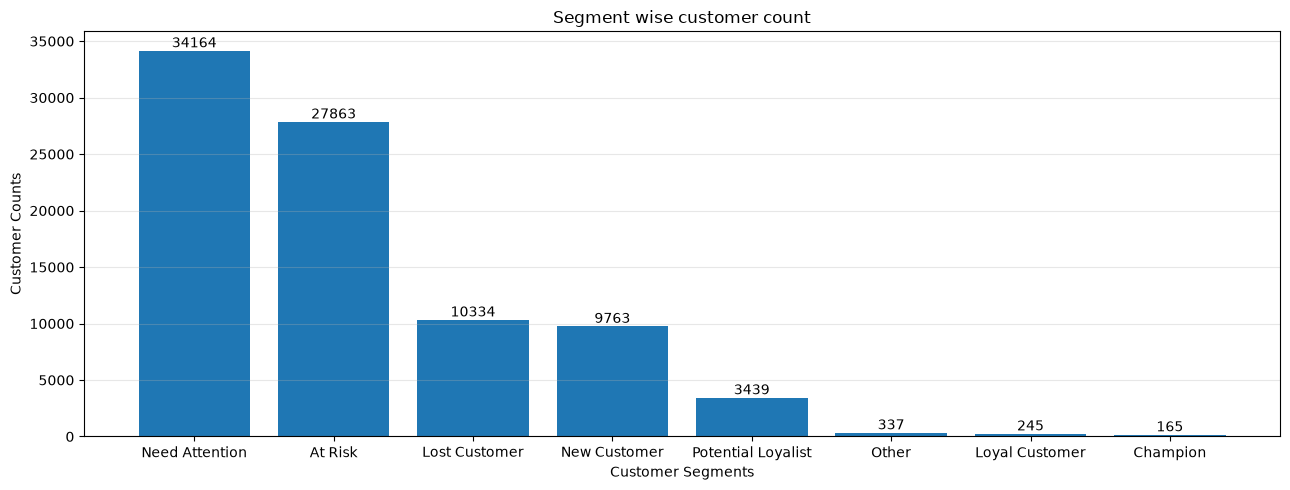

In [11]:
customer_count_sorted_summary = segment_summary.sort_values(by='Customer Count' , ascending= False)
plt.figure(figsize=(13,5))
bar1 = plt.bar(customer_count_sorted_summary.index, customer_count_sorted_summary['Customer Count'])
plt.ylabel("Customer Counts")
plt.xlabel("Customer Segments")
plt.title("Segment wise customer count")
plt.bar_label(bar1)
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

## Chart 2 — Total Revenue by Segment

Compares total revenue generated by each segment. Bar labels are shown in millions for readability.

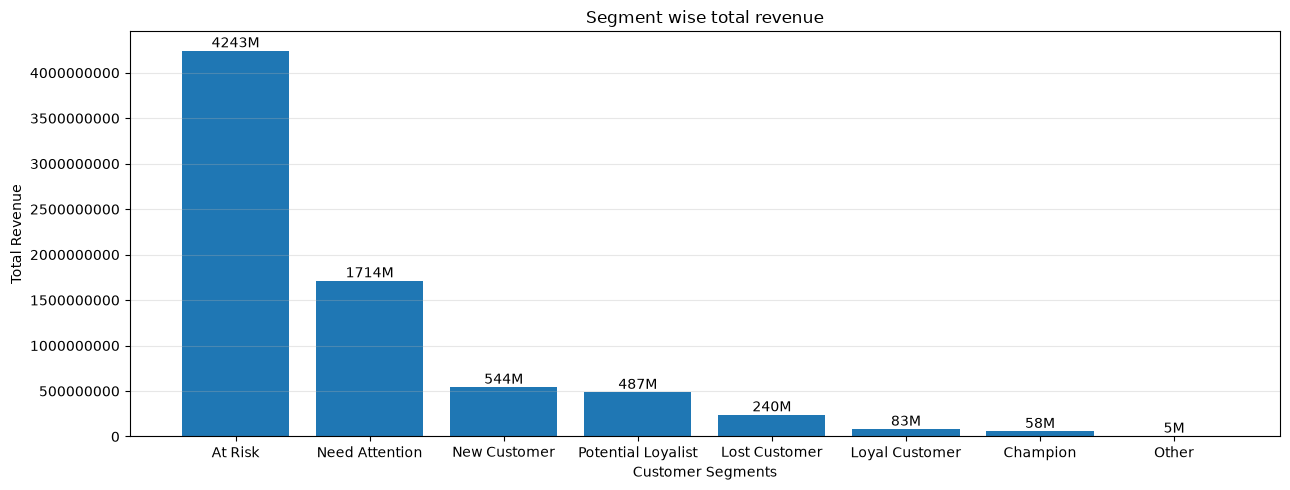

In [12]:
total_revenue_sorted_summary = segment_summary.sort_values(by='Revenue' , ascending= False)
plt.figure(figsize=(13,5))
bar2 = plt.bar(total_revenue_sorted_summary.index, total_revenue_sorted_summary['Revenue'])
plt.xlabel("Customer Segments")
plt.ylabel("Total Revenue")
plt.title("Segment wise total revenue")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.bar_label(bar2, fmt=lambda x: f'{x/1_000_000:.0f}M')
plt.show()

## Chart 3 — Revenue Contribution by Segment

Shows each segment's share of total customer revenue. Percentages below 2% are hidden inside the pie to reduce crowding.

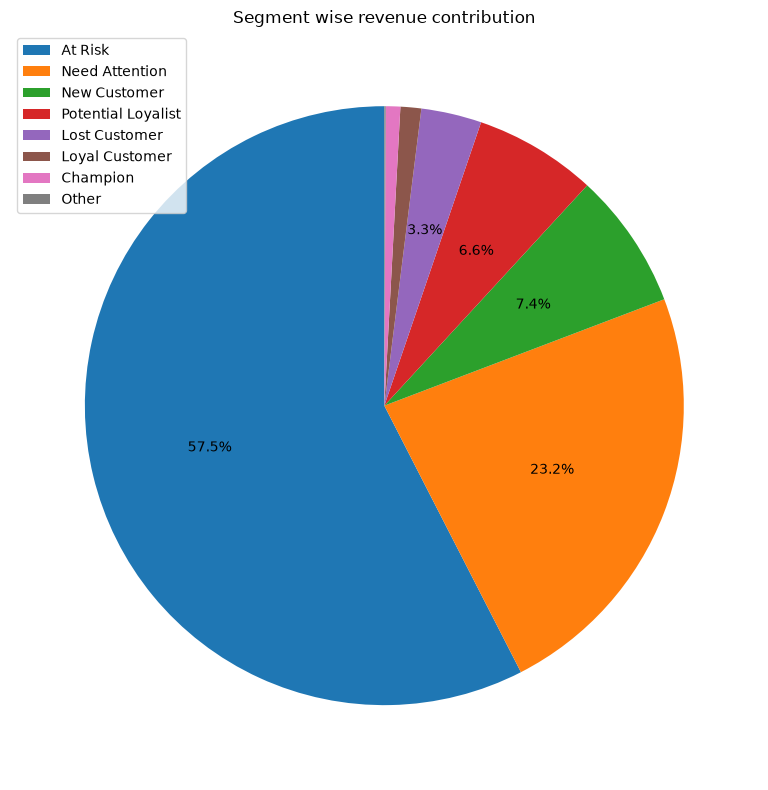

In [13]:
revenue_contribution_sorted_summary = segment_summary.sort_values(by='Revenue Contribution', ascending=False)
plt.figure(figsize=(8,8))
pie1 = plt.pie(revenue_contribution_sorted_summary['Revenue Contribution'], autopct=lambda pct: f'{pct:.1f}%' if pct >= 2 else '', startangle=90)
plt.legend(revenue_contribution_sorted_summary.index)
plt.title("Segment wise revenue contribution")
plt.tight_layout()
plt.show()

## Chart 4 — Average Revenue per Customer

Compares average customer revenue across segments.

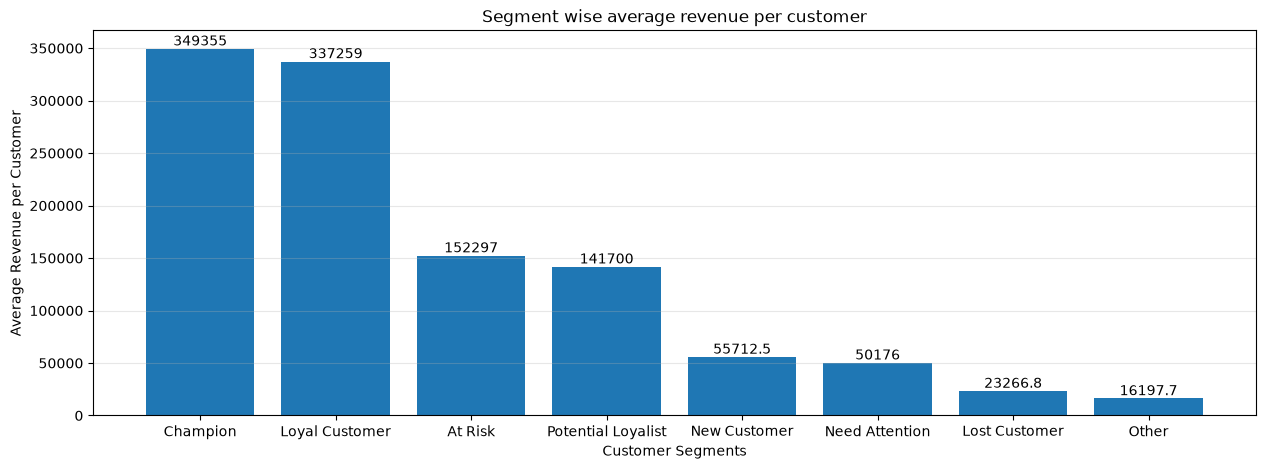

In [14]:
plt.figure(figsize=(15,5))
avg_revenue_sorted_summary = segment_summary.sort_values(by='Avg Revenue', ascending=False)
bar4 = plt.bar(avg_revenue_sorted_summary.index, avg_revenue_sorted_summary['Avg Revenue'])
plt.xlabel("Customer Segments")
plt.ylabel("Average Revenue per Customer")
plt.title("Segment wise average revenue per customer")
plt.grid(axis='y', alpha=0.3)
plt.bar_label(bar4)
plt.show()

## Chart 5 — Total Orders by Segment

Compares total lifetime orders generated by customers in each segment.

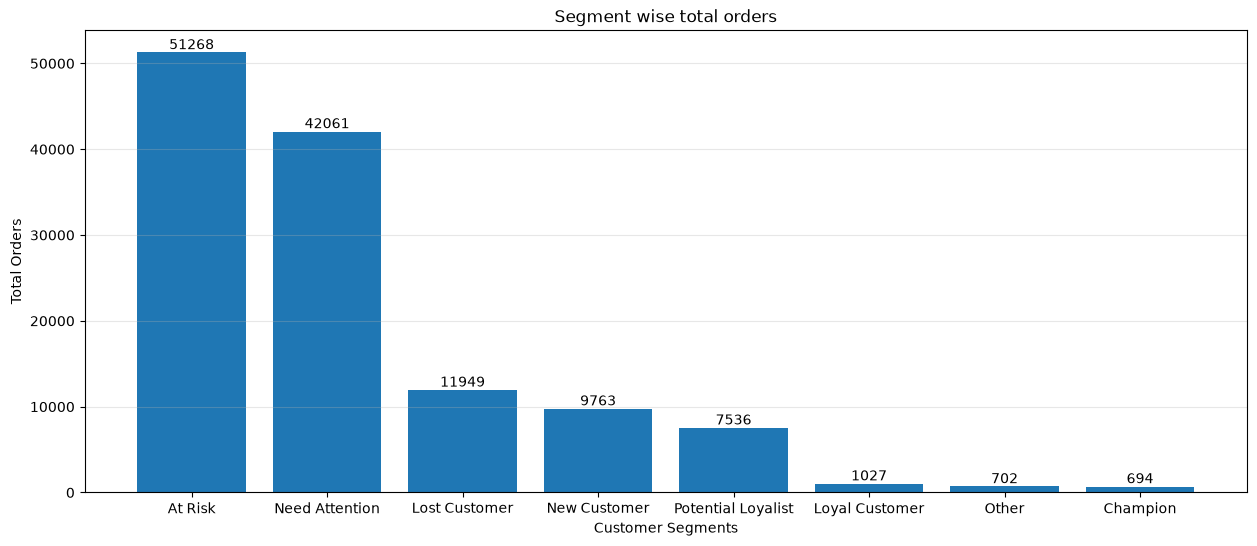

In [15]:
plt.figure(figsize=(15,6))
total_orders_sorted_summary = segment_summary.sort_values(by='Total Orders', ascending=False)
bar5 = plt.bar(total_orders_sorted_summary.index, total_orders_sorted_summary['Total Orders'])
plt.xlabel("Customer Segments")
plt.ylabel("Total Orders")
plt.title("Segment wise total orders")
plt.grid(axis='y', alpha=0.3)
plt.bar_label(bar5)
plt.show()

## Chart 6 — Average Orders per Customer

Compares the average number of orders per customer across segments.

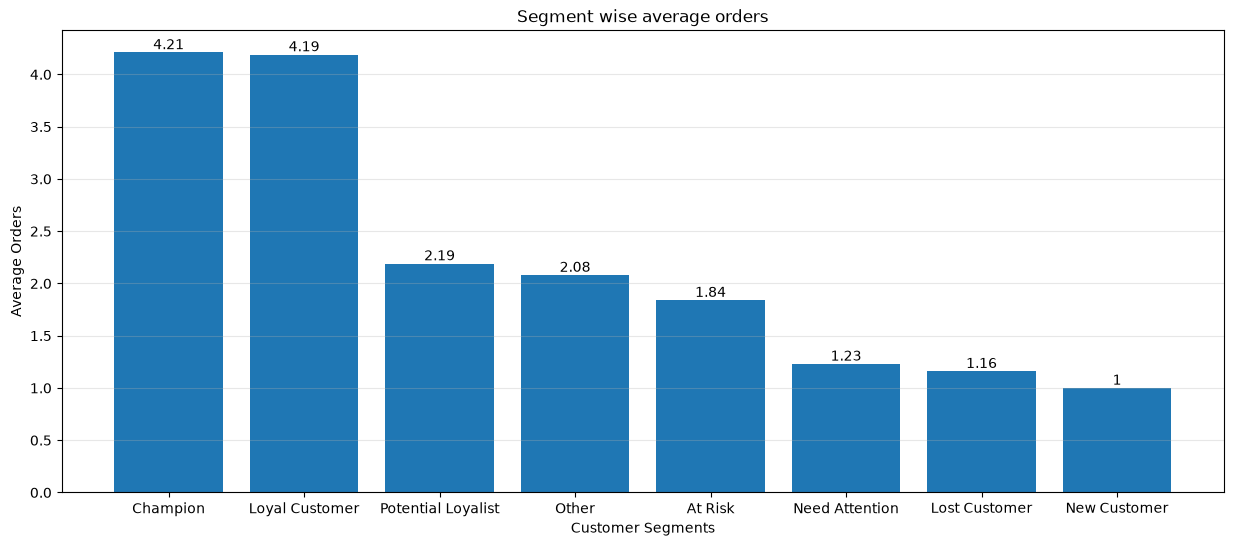

In [16]:
plt.figure(figsize=(15,6))
avg_orders_sorted_summary = segment_summary.sort_values(by='Average Orders', ascending=False)
bar6 = plt.bar(avg_orders_sorted_summary.index, avg_orders_sorted_summary['Average Orders'])
plt.xlabel("Customer Segments")
plt.ylabel("Average Orders")
plt.title("Segment wise average orders")
plt.grid(axis='y', alpha=0.3)
plt.bar_label(bar6)
plt.show()

## Chart 7 — Average Recency by Segment

Compares the average number of days since the most recent purchase. Lower recency means the segment purchased more recently.

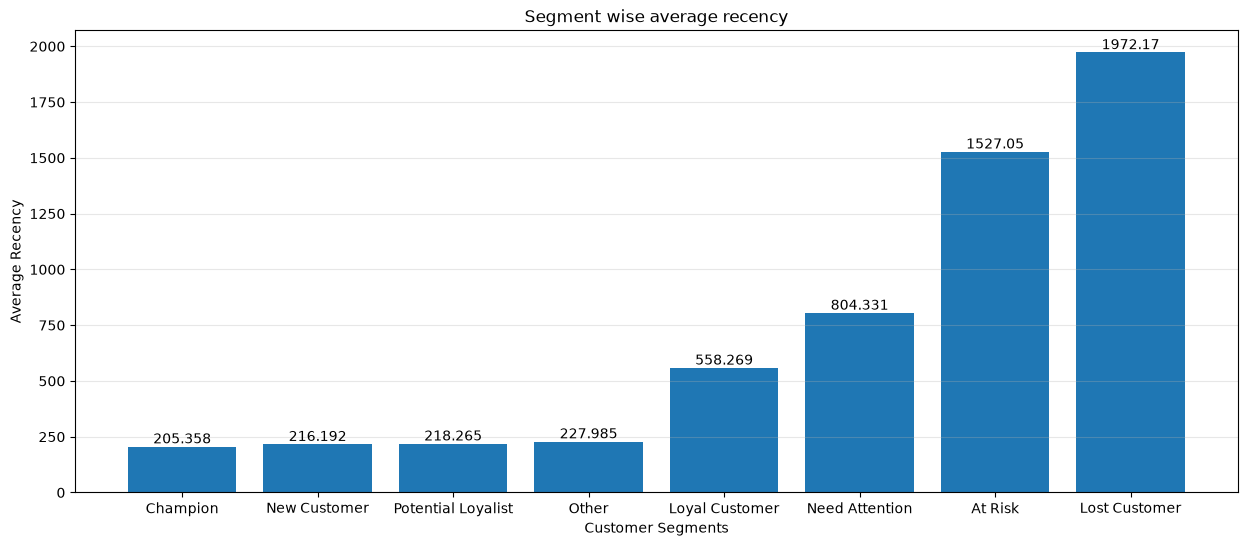

In [17]:
plt.figure(figsize=(15,6))
avg_recency_sorted_summary = segment_summary.sort_values(by='Avg Recency', ascending=True)
bar7 = plt.bar(avg_recency_sorted_summary.index, avg_recency_sorted_summary['Avg Recency'])
plt.xlabel("Customer Segments")
plt.ylabel("Average Recency")
plt.title("Segment wise average recency")
plt.grid(axis='y', alpha=0.3)
plt.bar_label(bar7)
plt.show()

# 11. Business Insights

### 1. Historical Revenue Is Heavily Concentrated in Weakening Customer Segments

The **At Risk** and **Need Attention** segments together contribute approximately **80.78% of total historical customer revenue**. At Risk customers alone account for **57.54%**, despite having an average recency of approximately **1,527 days**, while Need Attention contributes another **23.24%** with an average recency of approximately **804 days**.

This indicates significant **customer-retention exposure**: a large proportion of Vovers' historical revenue has been generated by customers whose purchasing activity has weakened considerably.

### 2. Champions and Loyal Customers Have Excellent Customer-Level Economics but Very Limited Scale

Champions and Loyal Customers contain only **165 and 245 customers**, respectively, yet they have the strongest customer-level performance. Champions generate approximately **₹349,355 average revenue per customer** with **4.21 average orders**, while Loyal Customers generate approximately **₹337,259** with **4.19 average orders**.

Their low total revenue contribution is therefore not caused by poor customer quality, but primarily by their **very small customer populations**. Vovers has demonstrated that highly engaged customers can become extremely valuable, but relatively few customers currently reach these high-value segments.

### 3. New Customers and Potential Loyalists Create a Meaningful Customer-Development Pipeline

Vovers has **9,763 New Customers**, representing a sizeable pool of customers who have made their first purchase. Potential Loyalists, although smaller at **3,439 customers**, already generate approximately **₹141,700 average revenue** and **2.19 average orders per customer**, compared with approximately **₹55,712** and **1.00 order** for New Customers.

This suggests an important opportunity to encourage second purchases among New Customers and progressively develop suitable customers toward **Potential Loyalist, Loyal Customer, and Champion** behavior.

### 4. Total Segment Contribution and Individual Customer Value Tell Different Stories

Large segments such as At Risk and Need Attention dominate total revenue because of their substantial customer populations, while much smaller Champion and Loyal Customer segments generate significantly greater revenue **per customer**.

Therefore, evaluating segments solely on total revenue contribution could be misleading. Vovers should consider both **segment scale and customer-level value** when determining customer priorities.

### 5. At Risk Customers Represent a Stronger Reactivation Opportunity Than Lost Customers

At Risk customers have historically generated approximately **₹152,297 average revenue per customer**, compared with only **₹23,267** among Lost Customers. Lost Customers also have the highest average recency at approximately **1,972 days**, compared with approximately **1,527 days** for At Risk customers.

Although both groups exhibit substantial inactivity, the historical value of At Risk customers makes them a stronger candidate for prioritized reactivation efforts. Lost Customers are likely to warrant a more selective, lower-cost recovery approach.

<br/>

---


# 12. Recommendations

### 1. Prioritize Retention and Reactivation of High-Value At Risk Customers

Vovers should identify the highest-value customers within the **At Risk** segment and use targeted win-back campaigns, personalized offers, product recommendations, or loyalty incentives rather than treating all inactive customers equally.

### 2. Prevent Need Attention Customers From Deteriorating Into At Risk Status

Because **Need Attention** is the largest segment with **34,164 customers** and contributes **23.24% of revenue**, Vovers should establish proactive re-engagement campaigns before these customers become substantially more inactive.

### 3. Build a Structured Customer-Development Journey

New Customers should be encouraged toward a **second purchase**, while Potential Loyalists should receive targeted cross-sell, loyalty, and repeat-purchase initiatives designed to progress suitable customers toward **Loyal Customer** and **Champion** status.

### 4. Protect and Retain Champions and Loyal Customers

Despite their small populations, these customers demonstrate the strongest revenue and purchase behavior per customer. Vovers should focus on retaining them through loyalty benefits, personalized communication, priority service, relevant recommendations, and other high-value retention initiatives.

### 5. Use Selective Rather Than Broad Reactivation for Lost Customers

Given their long inactivity and relatively low historical customer value, expensive mass reactivation campaigns may have lower expected value. Vovers should prioritize low-cost campaigns or selectively target Lost Customers with stronger historical value.

<br/>

---